# Autoencoder For Dimension Reduction

## Goal
The original notebook built a small 3D dataset, added a noisy feature, and used an autoencoder to compress it back into 2 dimensions. I kept that idea, but rebuilt the workflow so it runs cleanly with only NumPy, scikit-learn, and Matplotlib.

## Data
We start with two synthetic clusters in 2D, then add one random noise feature. That gives the model a simple compression task: keep the signal and learn to ignore the extra dimension.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, silhouette_score

rng = np.random.default_rng(101)

X_2d, labels = make_blobs(
    n_samples=300,
    n_features=2,
    centers=2,
    cluster_std=1.0,
    random_state=101,
)
noise = rng.normal(size=(len(X_2d), 1))
X_3d = np.hstack([X_2d, noise])

features = pd.DataFrame(X_3d, columns=['x1', 'x2', 'x3_noise'])
features.head()

,x1,x2,x3_noise
0,-8.877721,-6.760078,-0.790152
1,0.630638,3.107075,-2.034625
2,-0.240609,2.820690,0.603302
3,-7.839091,-8.207545,0.744295
4,-10.972908,-7.390676,-0.309687


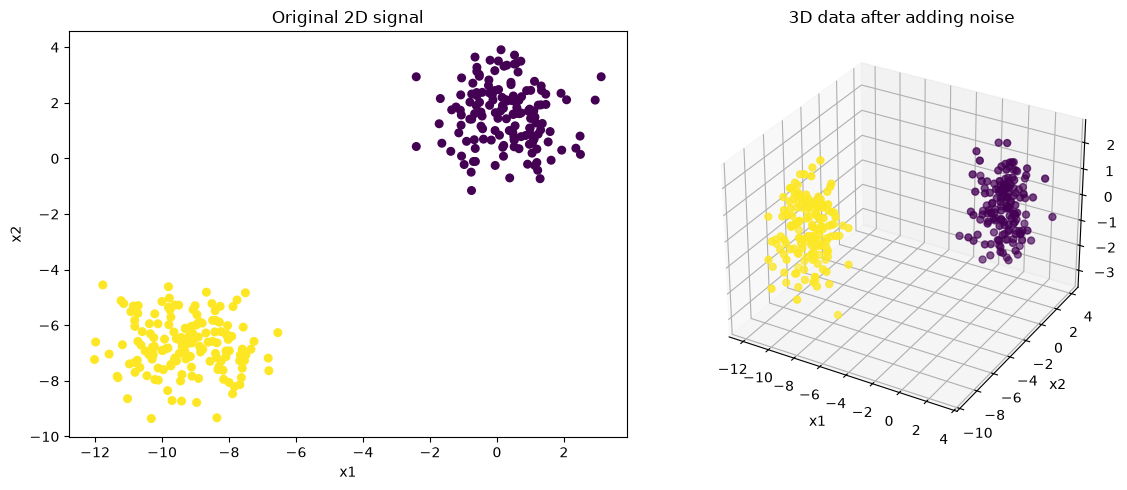

In [2]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
scatter = ax1.scatter(features['x1'], features['x2'], c=labels, cmap='viridis', s=30)
ax1.set_title('Original 2D signal')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(features['x1'], features['x2'], features['x3_noise'], c=labels, cmap='viridis', s=25)
ax2.set_title('3D data after adding noise')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('x3_noise')

plt.tight_layout()
plt.show()

## Model
I use a tiny fully connected autoencoder with a `3 -> 2 -> 3` shape. The encoder produces a 2D latent space, and the decoder tries to reconstruct the standardized input from that compact representation.

To keep the notebook easy to rerun anywhere, the network is trained with plain NumPy backpropagation instead of TensorFlow.

In [3]:
X_scaled = StandardScaler().fit_transform(features)

class TinyAutoencoder:
    def __init__(self, input_dim=3, latent_dim=2, seed=101):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 0.35, size=(input_dim, latent_dim))
        self.b1 = np.zeros((1, latent_dim))
        self.W2 = rng.normal(0, 0.35, size=(latent_dim, input_dim))
        self.b2 = np.zeros((1, input_dim))

    def encode(self, X):
        z = X @ self.W1 + self.b1
        return np.tanh(z)

    def reconstruct(self, H):
        return H @ self.W2 + self.b2

    def predict(self, X):
        H = self.encode(X)
        X_hat = self.reconstruct(H)
        return H, X_hat

    def fit(self, X, epochs=900, learning_rate=0.03):
        losses = []
        n = len(X)
        for epoch in range(epochs):
            H, X_hat = self.predict(X)
            error = X_hat - X
            loss = np.mean(error ** 2)
            losses.append(loss)

            dX_hat = 2 * error / n
            grad_W2 = H.T @ dX_hat
            grad_b2 = dX_hat.sum(axis=0, keepdims=True)

            dH = dX_hat @ self.W2.T
            dZ1 = dH * (1 - H ** 2)
            grad_W1 = X.T @ dZ1
            grad_b1 = dZ1.sum(axis=0, keepdims=True)

            self.W2 -= learning_rate * grad_W2
            self.b2 -= learning_rate * grad_b2
            self.W1 -= learning_rate * grad_W1
            self.b1 -= learning_rate * grad_b1
        return losses

model = TinyAutoencoder()
losses = model.fit(X_scaled)
latent_2d, reconstructed = model.predict(X_scaled)

final_mse = mean_squared_error(X_scaled, reconstructed)
cluster_score = silhouette_score(latent_2d, labels)

print(f'Final reconstruction MSE: {final_mse:.4f}')
print(f'Latent-space silhouette score: {cluster_score:.4f}')

Final reconstruction MSE: 0.0257
Latent-space silhouette score: 0.6586


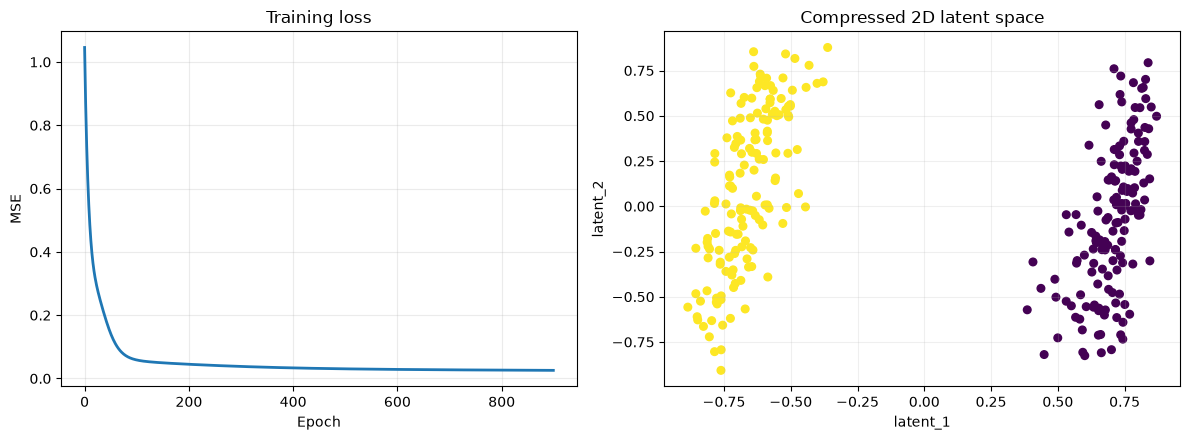

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(losses, color='tab:blue', linewidth=2)
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].grid(alpha=0.25)

axes[1].scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap='viridis', s=30)
axes[1].set_title('Compressed 2D latent space')
axes[1].set_xlabel('latent_1')
axes[1].set_ylabel('latent_2')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [5]:
comparison = pd.DataFrame({
    'original_x1': X_scaled[:5, 0],
    'recon_x1': reconstructed[:5, 0],
    'original_x2': X_scaled[:5, 1],
    'recon_x2': reconstructed[:5, 1],
    'original_noise': X_scaled[:5, 2],
    'recon_noise': reconstructed[:5, 2],
})
comparison.round(3)

,original_x1,recon_x1,original_x2,recon_x2,original_noise,recon_noise
0,-0.891,-0.958,-0.983,-0.972,-0.701,-0.767
1,1.050,1.134,1.338,1.113,-1.934,-1.650
2,0.872,1.030,1.271,1.043,0.681,0.731
3,-0.679,-1.049,-1.324,-1.039,0.820,0.904
4,-1.319,-1.129,-1.132,-1.135,-0.224,-0.201


## Result
The latent plot still separates the two blob groups, which means the encoder kept the useful structure even after compressing the noisy 3D input into 2 dimensions.

## What I Learned
A tiny autoencoder can act like a nonlinear compression tool: it keeps patterns that help reconstruction and pushes noisy details into a smaller role.

## Limits
This is a teaching example, not a benchmark. The dataset is synthetic, the network is shallow, and a stronger comparison against PCA would be a good next step if I wanted a more serious dimension-reduction study.